### Isolation Forest Trigger

This notebook illustrates how the IF trigger can be trained and used to extract anomalous waveforms from seismic data. 

For the illustration we consider data from ILL18 for 2018. We note the following:

1. Data should be contained in the folder "../data/XP/2018/ILL18/HHZ.D".
2. Output is stored in the folder "../output/illustration"

In [7]:
# imports
import obspy
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from joblib import dump, load

from seismicif.datamod.loading_utils import (
    preproc_flow_annotations,
    extract_split_flows,
)
from seismicif.datamod.trigger_utils import stream_trigger_detections
from seismicif.isolation_forest import train_if, compute_scores, create_if_stream
from seismicif.metrics import (
    iou,
    est_thresholds,
    compute_statistics,
    extract_valid_segments,
)

Train the isolation forest to miniseed recordings.

Note that the suffixes contain the day of the year, which we use to sort the files.

Training of the IF can take a couple of minutes

In [8]:
folder = "../data/XP/2018/ILL18/EHZ.D/"
stream_paths = [folder + f for f in os.listdir(folder) if not f.startswith("._")]
stream_paths = np.array(sorted(stream_paths, key=lambda f: int(f.rsplit(".", 1)[-1])))

try:
    if_mod = load("../output/illustration/ILL18_mod.joblib")

except (FileNotFoundError, OSError):
    if_mod = train_if(stream_paths)
    dump(if_mod, "../output/illustration/ILL18_mod.joblib")

Next we run the trained isolation forest over the training and/or testing period and extract time series of the anomaly scores.

Notes:
1. The miniseed files we worked with correspond to a given day. When we extract sliding windows, there can be a small amount of the waveform towards the end of the day that is not accessed, because it is not sufficiently long to form a full window. In such cases the waveform of the next day (if available) is appended to this residual waveform.
2. The function below takes a few minutes to run if the scores have not been stored. 
3. The dataframe is converted into an obspy stream for further analysis

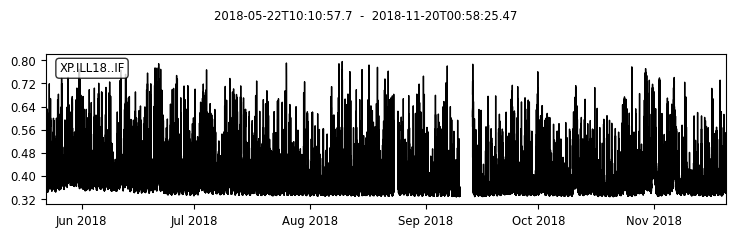

In [11]:
try:
    scores_df = pd.read_csv("../output/illustration/ILL18_scores.csv", index_col=0)
    # The conversion to UTCDateTime takes  few seconds
    scores_df["start"] = [obspy.UTCDateTime(str(i)) for i in scores_df["start"]]
    scores_df["stop"] = [obspy.UTCDateTime(str(i)) for i in scores_df["stop"]]

except (FileNotFoundError, OSError):
    scores_df = compute_scores(stream_paths, if_mod)
    scores_df.to_csv("../output/illustration/ILL18_scores.csv")

if_st = create_if_stream(scores_df, station="ILL18", sr=0.02, network="XP")

if_st.plot()
plt.show()

We can extract anomalous waveforms using rule-of-thumb thresholds.

In [15]:
onset_thres, offset_thres = 0.6, 0.55
if_segments = stream_trigger_detections(if_st, onset_thres, offset_thres)
if_segments.head()

,start,stop,most_anomalous_start,scores
0,2018-05-22T11:28:26.920000Z,2018-05-22T11:45:06.920000Z,2018-05-22T11:30:56.920000Z,0.797502
1,2018-08-09T14:31:43.580002Z,2018-08-09T15:20:53.580002Z,2018-08-09T14:53:23.580002Z,0.796016
2,2018-07-25T16:45:53.520019Z,2018-07-25T17:36:43.520019Z,2018-07-25T16:56:43.520019Z,0.790767
3,2018-05-22T11:46:46.920000Z,2018-05-22T11:58:26.920000Z,2018-05-22T11:48:26.920000Z,0.790681
4,2018-06-21T14:08:23.740003Z,2018-06-21T14:22:33.740003Z,2018-06-21T14:12:33.740003Z,0.788348


Alternatively, we can calibrate thresholds to a catalogue, assuming availability. The paper contains more detail on this.

In [28]:
flows = preproc_flow_annotations(pd.read_csv("../catalogs/XP/flow_catalog.csv"))
lower_conf_flows, high_conf_flows, all_flows = extract_split_flows(
    flows, "ILL18", 2018, 2018
)

# extract days with at least one segment in the catalog
# and create a stream with all segments for each day
dates = []
for i in range(all_flows.shape[0]):
    dates.append(all_flows["start"].iloc[i].date)
    dates.append(all_flows["stop"].iloc[i].date)
dates = np.array(dates)
dates = np.unique(dates)

st = obspy.Stream()
for dt in dates:
    start = obspy.UTCDateTime(f"{dt}T00:00:00")
    end = obspy.UTCDateTime(f"{dt}T23:59:59.999999")
    st += if_st.copy().trim(start, end)

# capture the segments in the catalog as well as possible
onset_grid = np.array([0.55, 0.60, 0.65, 0.70])
offset_grid = np.array([0.50, 0.55, 0.60, 0.65])

iou_table = np.zeros([len(onset_grid), len(offset_grid)])
for i in range(onset_grid.shape[0]):
    for j in range(offset_grid.shape[0]):
        if onset_grid[i] < offset_grid[j]:
            continue

        segments = stream_trigger_detections(st, onset_grid[i], offset_grid[j])
        inter, union, _ = iou(segments, all_flows)
        iou_table[i, j] = inter[-1] / union[-1]

max_idx = np.unravel_index(np.argmax(iou_table), iou_table.shape)
onset_thres, offset_thres = onset_grid[max_idx[0]], offset_grid[max_idx[1]]

print(f"max iou: {100 * iou_table[max_idx]:.2f}%")
print(f"onset_thres: {onset_thres}, offset_thres: {offset_thres}")
if_segments = stream_trigger_detections(if_st, onset_thres, offset_thres)
if_segments.to_csv("../output/illustration/ILL18_segments.csv")

max iou: 67.54%
onset_thres: 0.7, offset_thres: 0.5
